# Figure 5: ARISTA

Draw Figure 5 from generated cell states, communication scores, and per-cell
velocity and growth arrays. No completed figure is used as an input.

Run this notebook from the [source checkout](../../installation.md).
The first cell downloads the spatial populations, communication scores and
lineage labels. The velocity and growth arrays are included with the code.

The [ARISTA analysis tutorial](../dataset_workflows/arista.ipynb) shows how to
load the trained model, simulate populations and evaluate growth. Here we use
the saved paper populations and velocity arrays to reproduce the displayed panels.
The spatial display uses the same coordinate anchoring as the paper. This
changes the plotted coordinates, not the model's state or cell-type labels.
To regenerate these populations, follow [Generate the ARISTA paper populations](arista_populations.md).

In [1]:
import os
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
data = project / "data/arista/paper"
if not (data / "all_time_communications.pkl").is_file():
    cb.datasets.download("arista", destination=project,
                         kind="arista_figure_data.zip")
output = Path("outputs/arista_paper")
output.mkdir(parents=True, exist_ok=True)

def show(paths):
    for path in paths:
        if Path(path).suffix == ".png":
            display(Image(filename=str(path), width=850))

if not (data / "display_states/time_0.h5ad").is_file():
    cb.datasets.download("arista", destination=project,
                         kind="arista_spatial_display_data.zip")

In [2]:
from reproduction.arista.main_figure import draw_main_figure

## a. Spatial dynamics

Calculate the spatial anchors and draw lineage transitions and cell-type communication between the five populations.

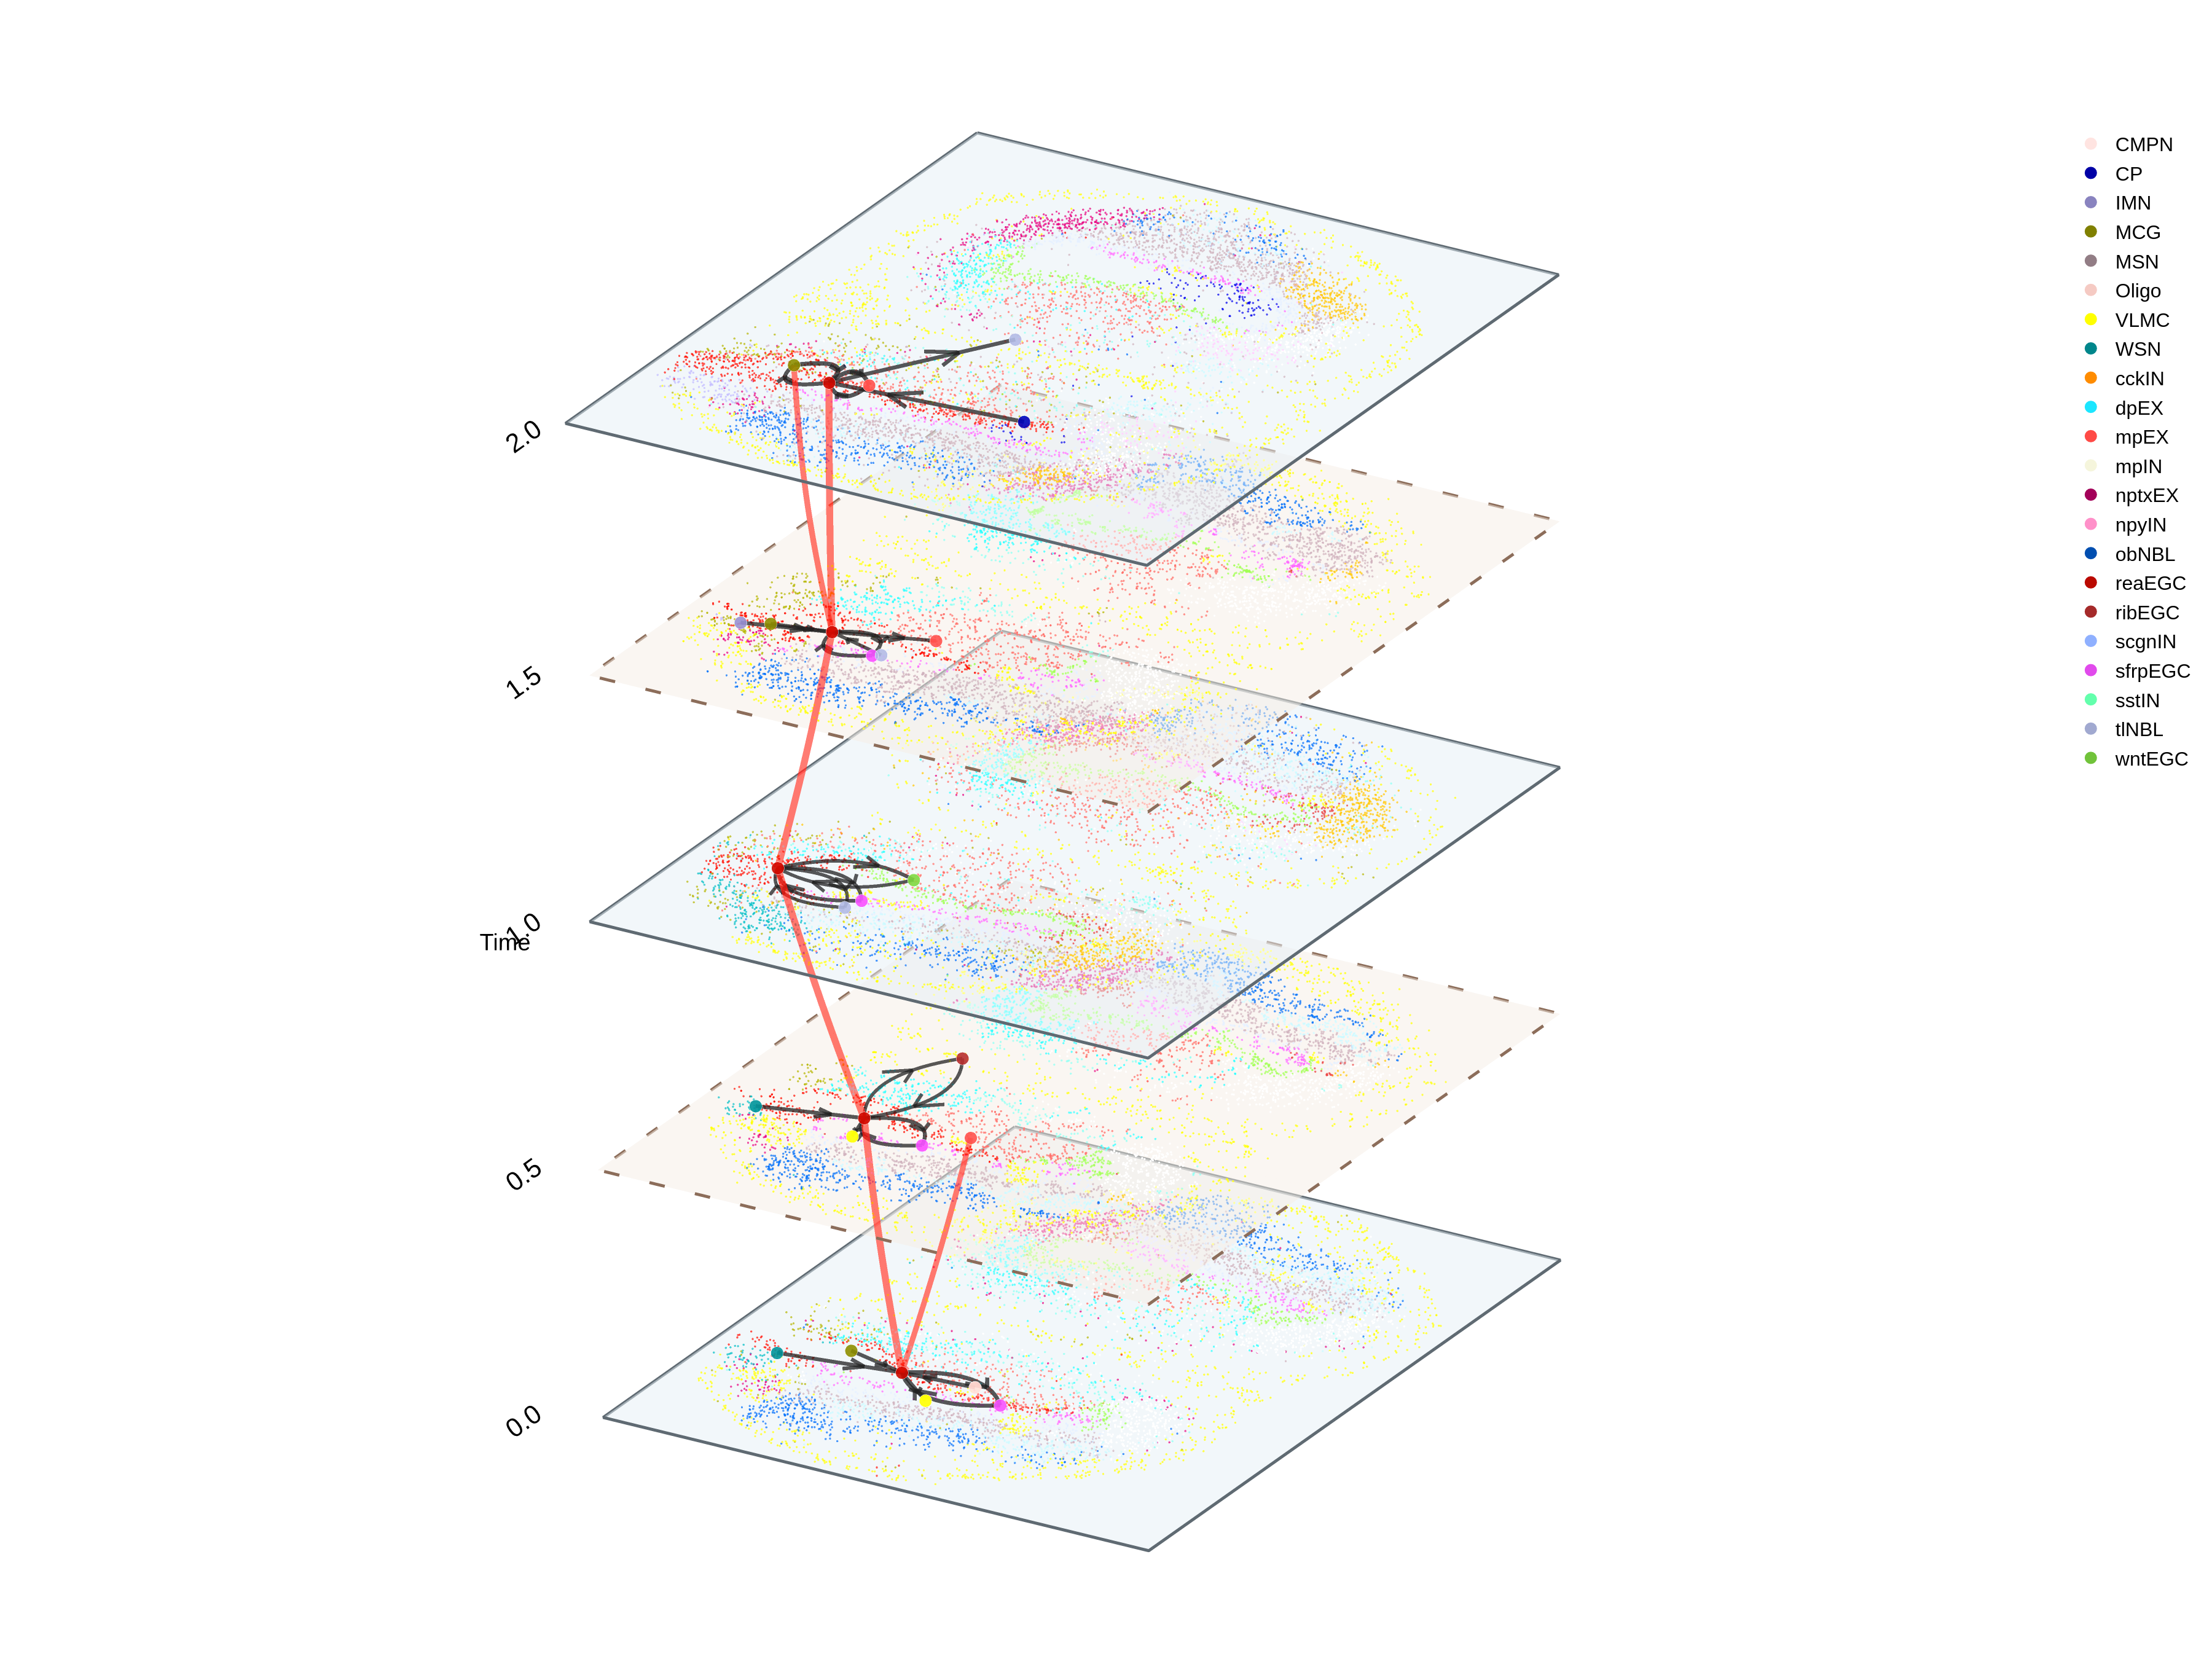

In [3]:
figures = draw_main_figure(data, output, panels="a")
show(figures["a"])

## b. Generated population

Plot the generated population at the intermediate time point using the paper’s cell-type colours.

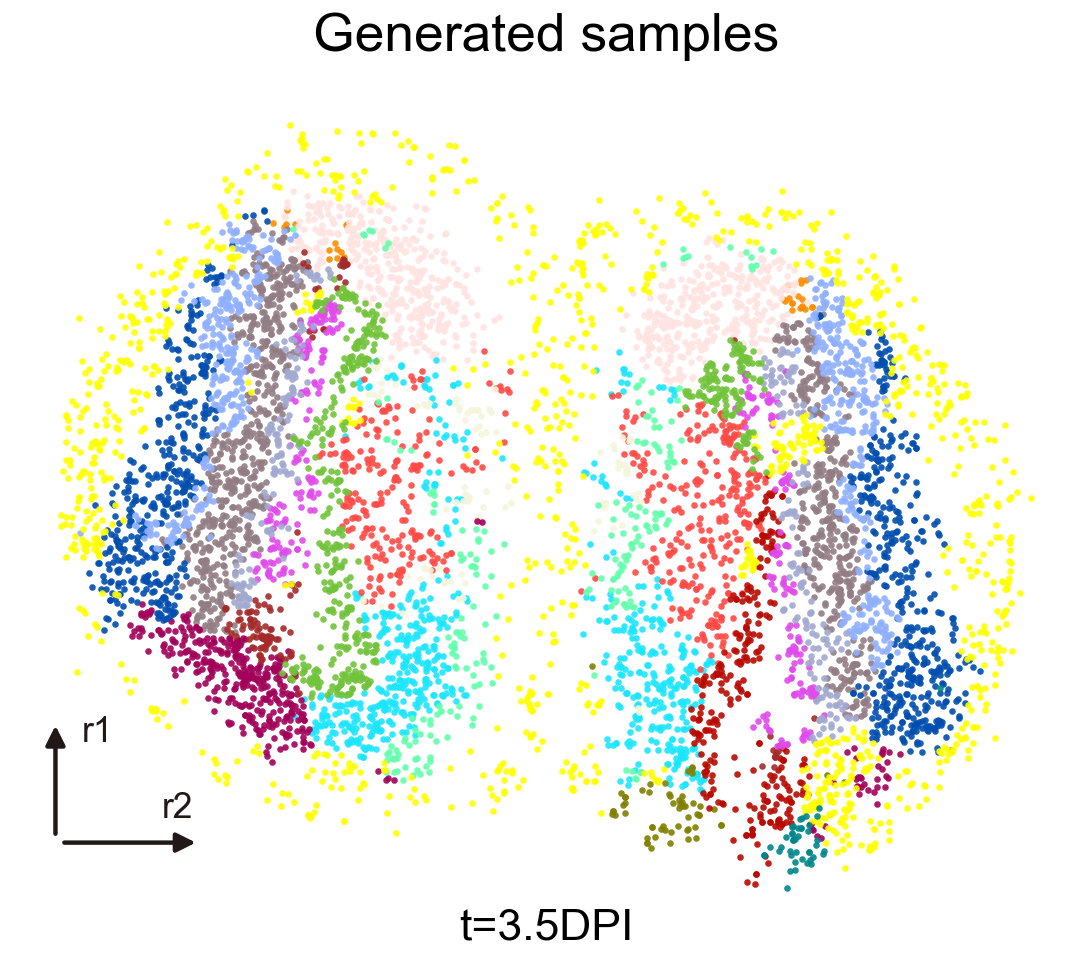

In [4]:
figures = draw_main_figure(data, output, panels="b")
show(figures["b"])

## c. Spatial velocity

Calculate the full-versus-interaction velocity cosine for each cell and the spatial velocity grid. The right panel enlarges the selected region.

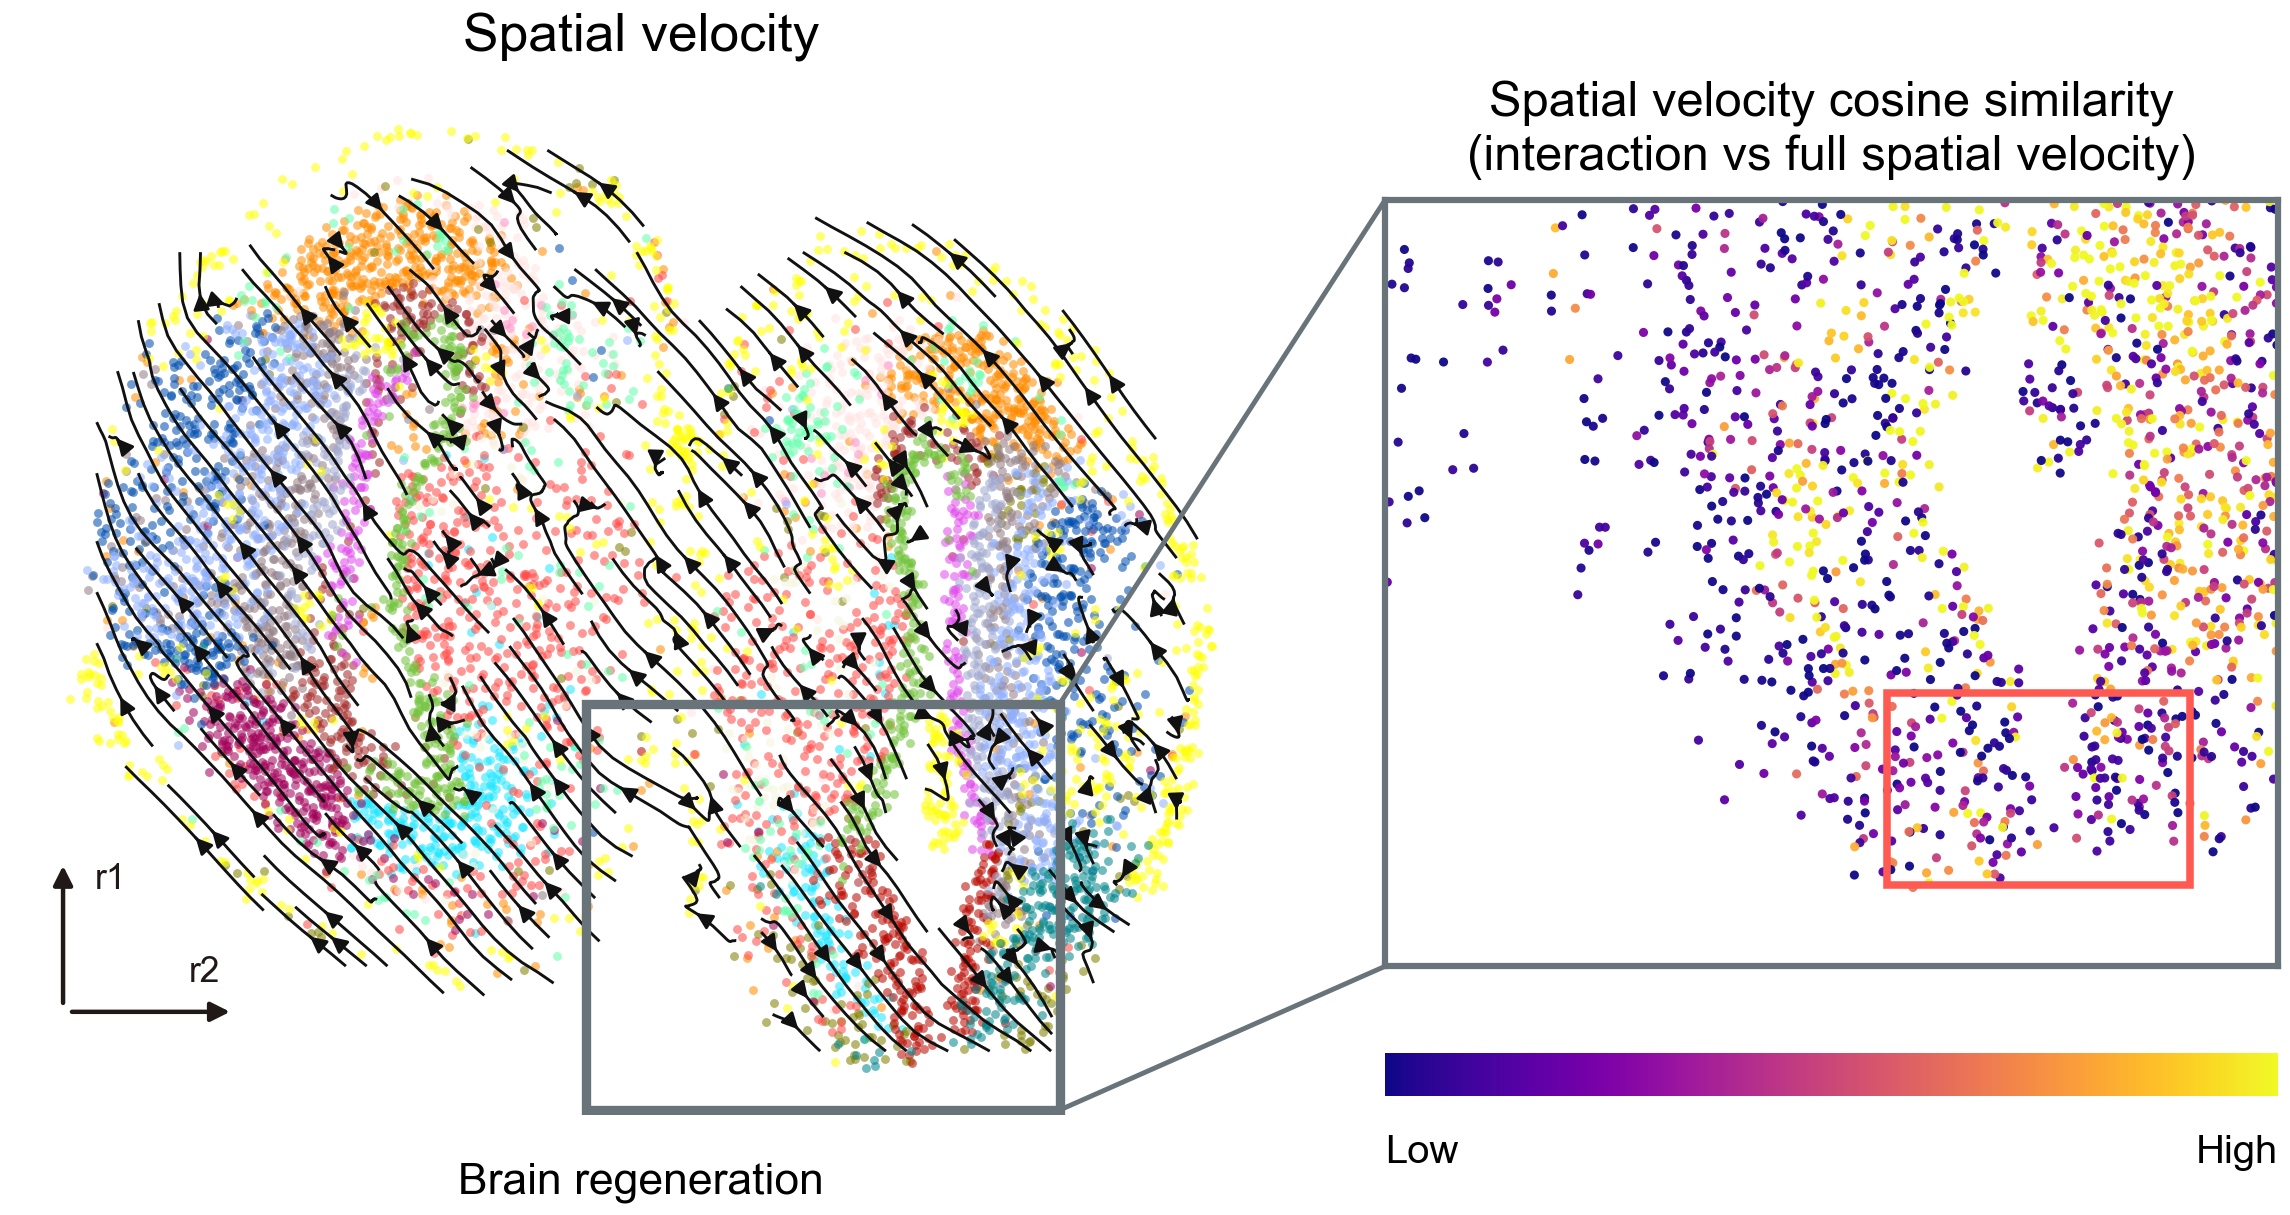

In [5]:
figures = draw_main_figure(data, output, panels="c")
show(figures["c"])

## d. Gene velocity

Interpolate the full gene-velocity vectors in PCA space and draw the streamlines over the cells.

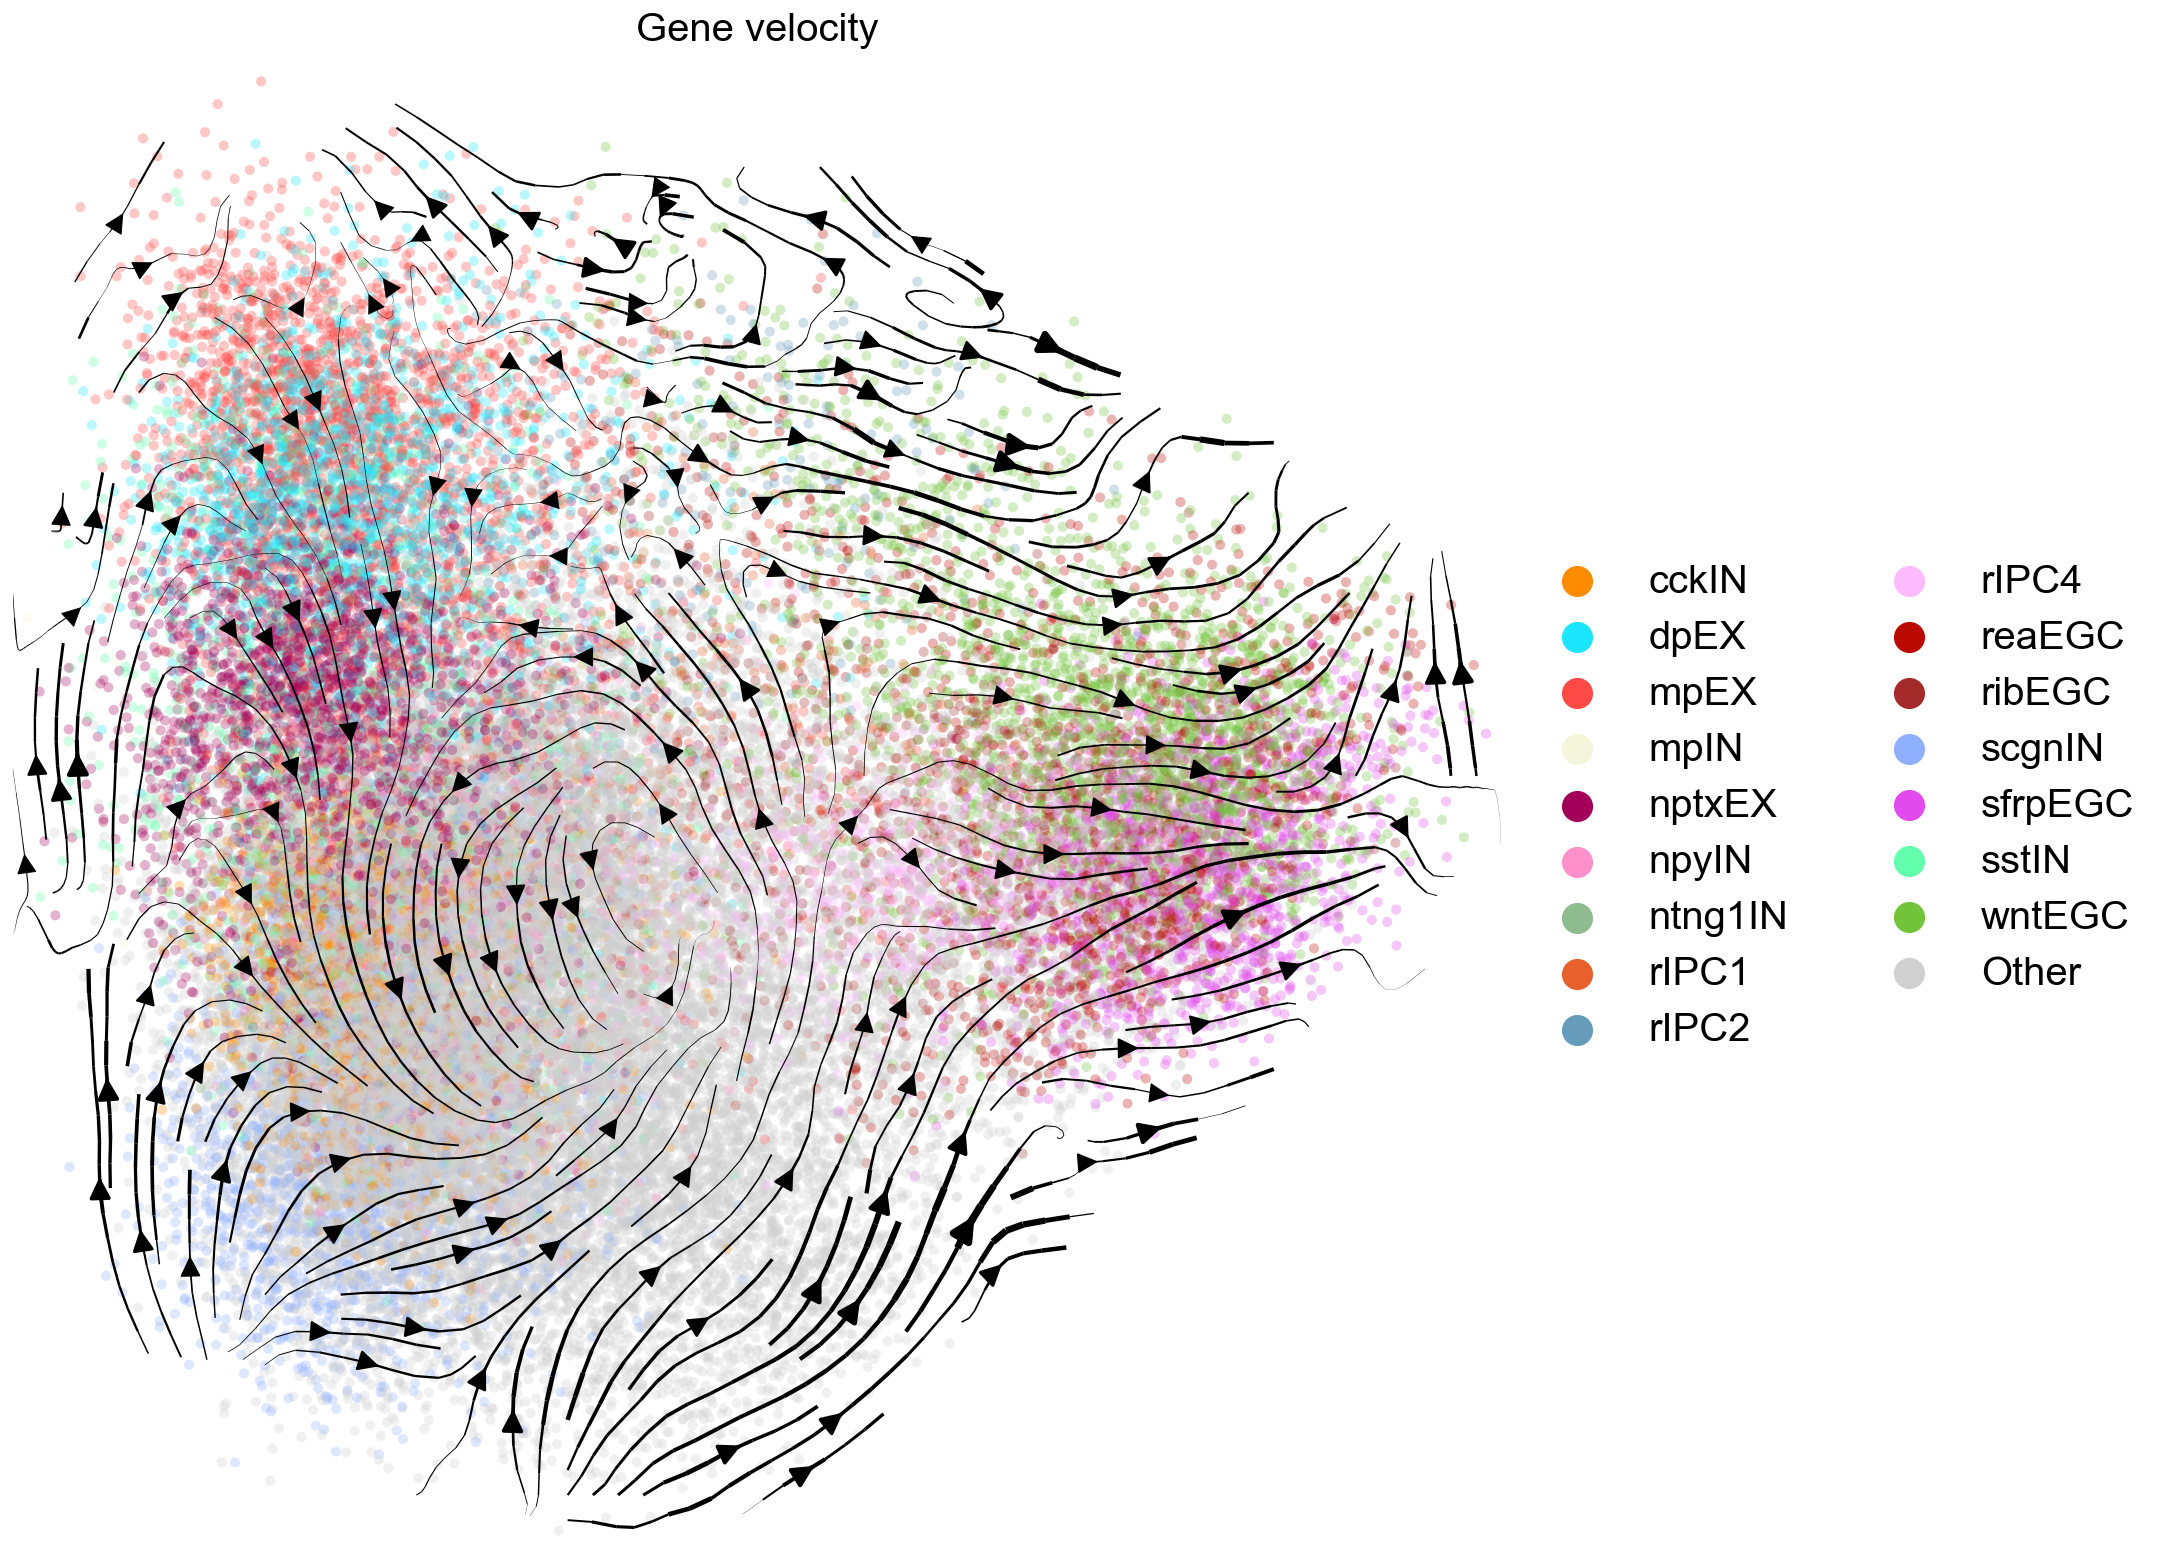

In [6]:
figures = draw_main_figure(data, output, panels="d")
show(figures["d"])

## e. Growth and interaction

Group the per-cell values by time and cell type, calculate the means, and draw the growth–interaction comparison.

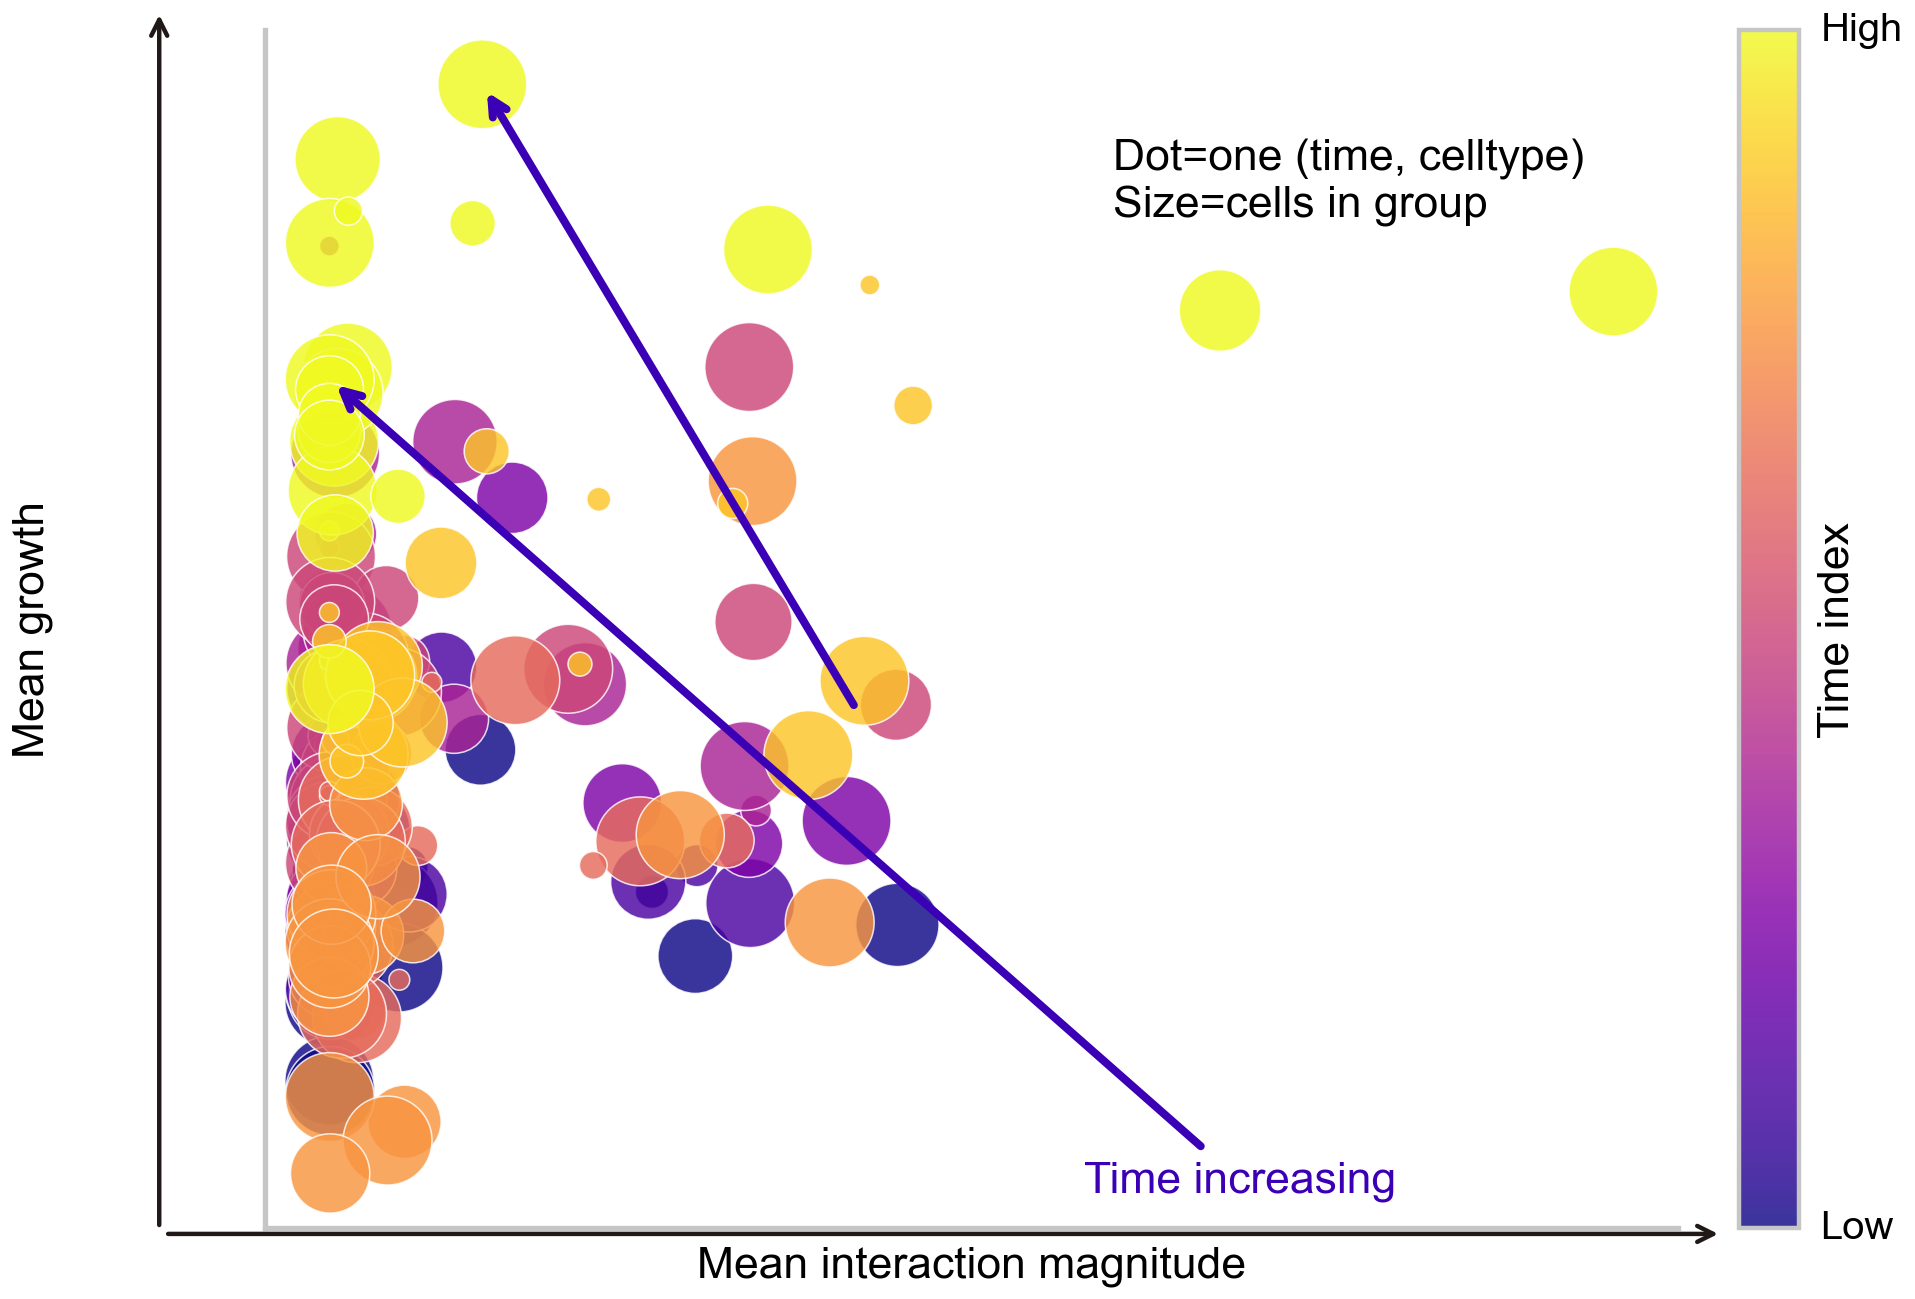

In [7]:
figures = draw_main_figure(data, output, panels="e")
show(figures["e"])